## **Esimated CDF for SM**

Using a fitted polynomial or exponential function may smooth the tail of the distribution too much, eliminating events that are clustered on the far right, effectivly ignoring all the new physics. Instead, it is possible to make a CDF based on a histogram of discrete values that is smoothed only by choosing the number of bins. This will be a naively constructed, piecewise-continuous function. This can be normalized in both X and Y directions, so CDF(GeV) returns a correct value and sum(CDF(Gev)) = 1.0 .

In [2]:
import os
import pickle
import numpy as np
from pathlib import Path
import mg5qs_import as qs

path = Path('pT_example_4')
pTs = np.empty((0), dtype=np.float64)

for fname in os.listdir(path):
    if 'pkl' in fname:
        with open(path / fname, 'rb') as f:
            params, pT = pickle.load(f)
            pTs = np.concatenate([pTs, pT[1]])

pTs.shape, np.max(pTs)

((1417859,), np.float64(662.1187980538025))

In [3]:
BINS = int(np.ceil(np.max(pTs)))  # this is convenient because it equates to 1 GeV per bin

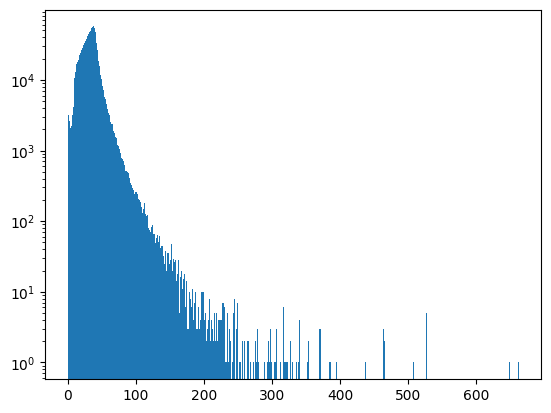

In [4]:
import matplotlib.pyplot as plt
plt.hist(pTs, bins=BINS, log=True)
plt.show()

### **Divide data into bins (with each bin representing 1 Gev), then normalize PDF to sum to 1.0:**

In [5]:
# divide into 1GeV bins
hist, edges = np.histogram(pTs, bins=BINS)

In [6]:
# normalize
pdf = hist / np.sum(hist)
sum(pdf)

np.float64(0.9999999999999988)

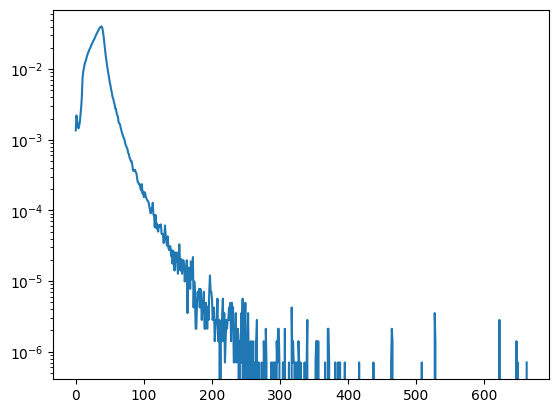

In [7]:
# PDF looks like a continous version of discrete histogram
plt.plot(pdf)
plt.yscale('log')
plt.show()

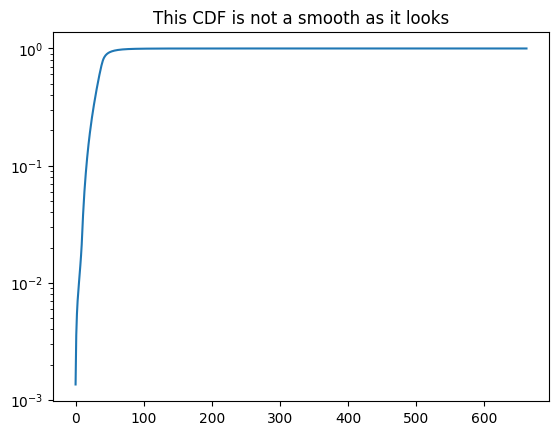

In [8]:
# calculate CDF from discrete PDF
cdf = np.cumsum(pdf)
plt.plot(cdf)
plt.yscale('log')
plt.title('This CDF is not a smooth as it looks')
plt.show()

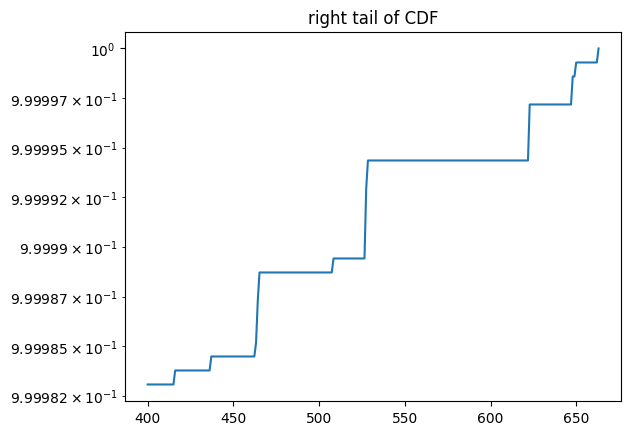

In [9]:
# zoom in
plt.plot(np.linspace(400,BINS,BINS-400), cdf[400:])
plt.yscale('log')
plt.title('right tail of CDF')
plt.show()

### **Create a cdf that takes GeV as input**

In [10]:
cdf[77]

np.float64(0.9883232394758578)

In [11]:
import math

gev = 100.2
width = edges[1]-edges[0]
location = gev/width
left = int(location)
v = cdf[left] + (cdf[left+1]-cdf[left]) * (location-np.floor(location))
v

np.float64(0.9960920187100359)

In [12]:
def my_cdf(gev):
    width = edges[1]-edges[0]
    location = gev/width
    left = location.astype(int)
    left = np.clip(left, 0, BINS-2)
    return cdf[left] + (cdf[left+1]-cdf[left]) * (location-np.floor(location))

### **Confirm that right tail is not smoothed**

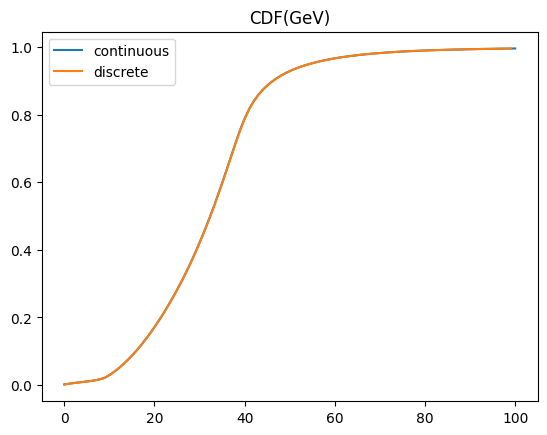

In [13]:
plt.plot(np.linspace(0,100,1000), my_cdf(np.linspace(0,100,1000)), label='continuous')
plt.plot(cdf[0:100], label='discrete')
plt.title('CDF(GeV)')
plt.legend()
plt.show()

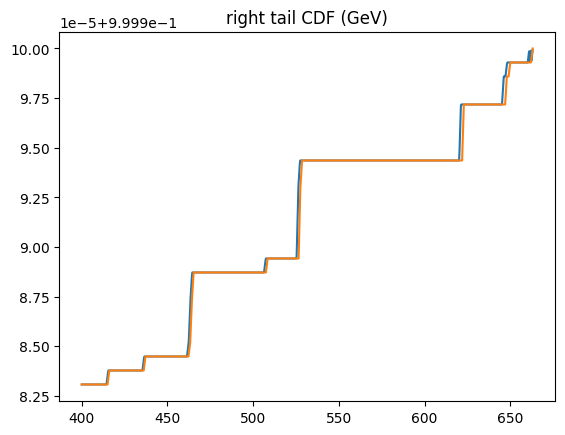

In [14]:
plt.plot(np.linspace(400,BINS,1000), my_cdf(np.linspace(400,BINS,1000)))
plt.plot(np.linspace(400,BINS,BINS-400), cdf[400:BINS])
plt.title('right tail CDF (GeV)') 
plt.show()

### **KS Test with discrete CDF: $O=n log(n)$**

In [15]:
import scipy.stats as stats
stats.kstest(stats.norm.rvs(loc=0, scale=1, size=100_000), my_cdf).statistic # not the same

np.float64(0.9920794994324186)

In [16]:
kstat = []
k2stat = []
for sample_size in np.logspace(3,6,10):
    for i in range(20):
        s = int(sample_size)
        start = np.random.randint(1_000_000)
        kstat.append((s,stats.kstest(pTs[start:start+s],my_cdf).statistic))
        k2stat.append((s,stats.ks_2samp(pTs[0+start:s+start],pTs[s:]).statistic))
kstat = np.array(kstat)
k2stat = np.array(k2stat)

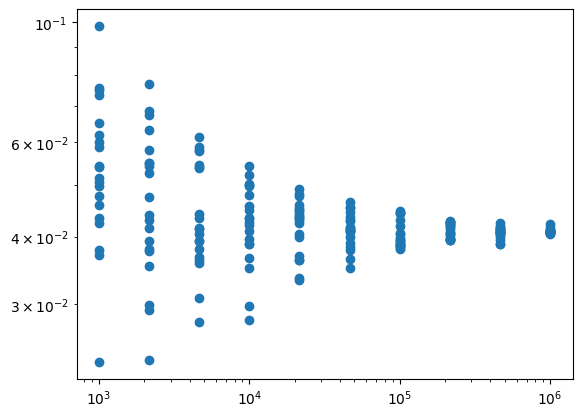

In [18]:
plt.scatter(kstat[:,0], kstat[:,1])
plt.xscale('log')
plt.yscale('log')

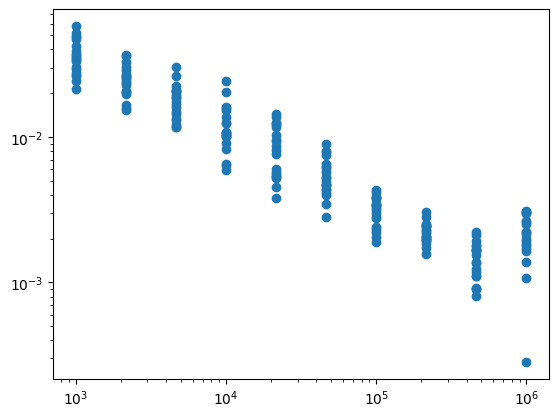

In [19]:
plt.scatter(k2stat[:,0], k2stat[:,1])
plt.xscale('log')
plt.yscale('log')

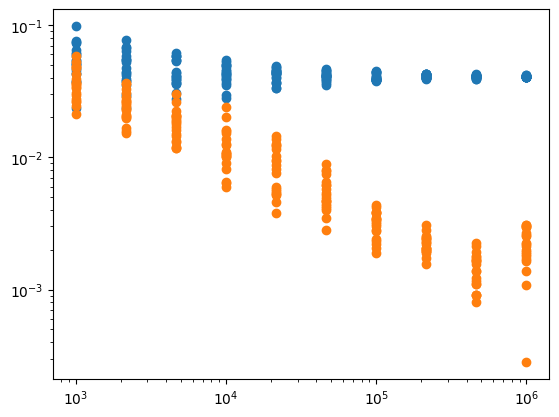

In [20]:
plt.scatter(kstat[:,0], kstat[:,1])
plt.scatter(k2stat[:,0], k2stat[:,1])
plt.xscale('log')
plt.yscale('log')

### **Use library function to create CDF**

In [27]:
params, pTs = qs.unpickle_pTs('pT_example_4')
sm_cdf = qs.DiscreteCDF(pTs, BINS)
sm_cdf.cdf(20.0), my_cdf(20.0)

(np.float64(0.15181026034473002), np.float64(0.17110262813724503))

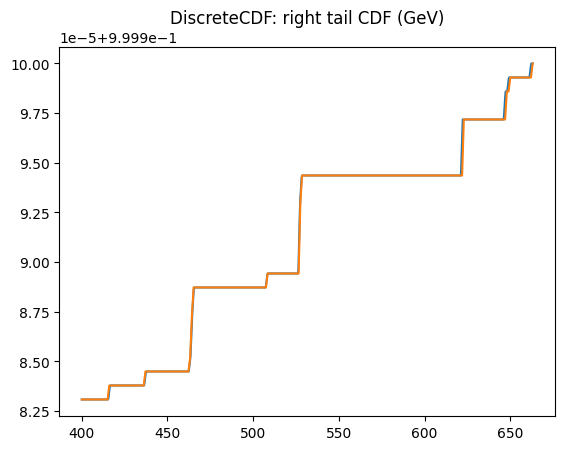

In [29]:
plt.plot(np.linspace(400,BINS,1000), sm_cdf.cdf(np.linspace(400,BINS,1000)))
plt.plot(np.linspace(400,BINS,BINS-400), cdf[400:BINS])
plt.title('DiscreteCDF: right tail CDF (GeV)') 
plt.show()